# Phase 3 — Cohort Analysis
## Retail Customer Analysis — UCI Online Retail II

**Goal of this phase:** measure how well the business retains customers over time.

We group customers into **monthly cohorts** based on the month of their first purchase, then
track what fraction keep buying in each following month. The result is a **retention matrix**
and **retention curve** — among the clearest indicators of business health, and the foundation
for the value and segmentation work in later phases.

**Data source:** `customers_clean` from PostgreSQL (only identifiable customers can be tracked
over time). Analysis covers **all regions combined**; the `region` flag is retained so a
UK / Non-UK split can be added later if cohorts diverge.

**Key terms:**
- **Cohort month** — the month a customer made their *first* purchase (their acquisition month).
- **Cohort index** — months elapsed since acquisition (0 = first month, 1 = one month later...).
- **Retention rate** — share of a cohort still active in a given month, relative to its size at index 0.


## 1. Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import getpass
from sqlalchemy import create_engine, text

pd.set_option('display.max_columns', None)
sns.set_style('white')
plt.rcParams['figure.figsize'] = (12, 7)

## 2. Load Data from PostgreSQL

We pull the columns needed for cohort analysis directly from the `customers_clean` table.
Using SQL to select only what we need keeps the data small and demonstrates the database as
the single source of truth.

In [2]:
# Connect using local trust auth (same approach as Phase 2 — no password)
username = getpass.getuser()
engine = create_engine(f'postgresql+psycopg2://{username}@localhost:5432/retail_db', future=True)

# Pull only the fields cohort analysis needs
query = 'SELECT customer_id, invoicedate, invoice, revenue FROM customers_clean'
df = pd.read_sql(query, engine)

# Ensure the date column is a proper datetime
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

print(f'Loaded {len(df):,} rows for {df["customer_id"].nunique():,} customers')
df.head(3)

Loaded 776,579 rows for 5,852 customers


,customer_id,invoicedate,invoice,revenue
0,13085,2009-12-01 07:45:00,489434,83.4
1,13085,2009-12-01 07:45:00,489434,81.0
2,13085,2009-12-01 07:45:00,489434,81.0


## 3. Build the Cohort Fields

Three new columns drive everything:
- `invoice_month` — the month of each transaction.
- `cohort_month` — the customer's first-purchase month (constant per customer).
- `cohort_index` — how many months after acquisition the transaction occurred.

In [3]:
# The month each transaction occurred (as a monthly period, e.g. 2010-03)
df['invoice_month'] = df['invoicedate'].dt.to_period('M')

# Each customer's first-ever purchase month — broadcast back to all their rows
df['cohort_month'] = (df.groupby('customer_id')['invoicedate']
                        .transform('min')
                        .dt.to_period('M'))

# Months elapsed since acquisition: (year diff * 12) + month diff
# Index 0 = the acquisition month itself
df['cohort_index'] = ((df['invoice_month'].dt.year  - df['cohort_month'].dt.year) * 12 +
                      (df['invoice_month'].dt.month - df['cohort_month'].dt.month))

df[['customer_id', 'invoice_month', 'cohort_month', 'cohort_index']].head()

,customer_id,invoice_month,cohort_month,cohort_index
0,13085,2009-12,2009-12,0
1,13085,2009-12,2009-12,0
2,13085,2009-12,2009-12,0
3,13085,2009-12,2009-12,0
4,13085,2009-12,2009-12,0


## 4. Count Active Customers per Cohort

For each (cohort month, months-since-acquisition) pair, count the **distinct customers** who
were active. We count unique customers — not transactions — because retention is about people,
not order volume.

In [4]:
# Distinct active customers for every cohort / index combination
cohort_data = (df.groupby(['cohort_month', 'cohort_index'])['customer_id']
                 .nunique()
                 .reset_index(name='customers'))

# Reshape into a matrix: one row per cohort month, one column per month-since-acquisition
cohort_counts = cohort_data.pivot(index='cohort_month',
                                  columns='cohort_index',
                                  values='customers')

cohort_counts.iloc[:, :8]   # preview first 8 month-columns

cohort_index,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2009-12,951.0,333.0,317.0,404.0,360.0,342.0,358.0,327.0
2010-01,368.0,79.0,118.0,116.0,100.0,114.0,99.0,86.0
2010-02,375.0,88.0,85.0,110.0,92.0,74.0,72.0,108.0
2010-03,441.0,84.0,102.0,107.0,102.0,90.0,109.0,135.0
2010-04,294.0,56.0,56.0,47.0,54.0,65.0,81.0,78.0
2010-05,255.0,40.0,43.0,45.0,45.0,65.0,54.0,32.0
2010-06,267.0,47.0,50.0,55.0,62.0,76.0,34.0,24.0
2010-07,185.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0
2010-08,163.0,32.0,47.0,53.0,27.0,19.0,16.0,21.0


## 5. Convert to Retention Rates

Each cohort's size is its customer count at index 0. Dividing every column by that size turns
raw counts into **retention percentages**, so cohorts of different sizes can be compared fairly.

In [5]:
# Cohort size = number of customers in their acquisition month (index 0)
cohort_sizes = cohort_counts[0]

# Divide each row by its index-0 size to get retention as a fraction (0-1)
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Show as percentages, rounded, for readability
(retention * 100).round(1).iloc[:, :8]

cohort_index,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2009-12,100.0,35.0,33.3,42.5,37.9,36.0,37.6,34.4
2010-01,100.0,21.5,32.1,31.5,27.2,31.0,26.9,23.4
2010-02,100.0,23.5,22.7,29.3,24.5,19.7,19.2,28.8
2010-03,100.0,19.0,23.1,24.3,23.1,20.4,24.7,30.6
2010-04,100.0,19.0,19.0,16.0,18.4,22.1,27.6,26.5
2010-05,100.0,15.7,16.9,17.6,17.6,25.5,21.2,12.5
2010-06,100.0,17.6,18.7,20.6,23.2,28.5,12.7,9.0
2010-07,100.0,15.7,18.4,29.7,29.2,14.1,11.4,14.6
2010-08,100.0,19.6,28.8,32.5,16.6,11.7,9.8,12.9


## 6. Retention Heatmap

The classic cohort view. Each row is an acquisition cohort; each column is months since
acquisition. Colour shows the share still active. The triangular shape is expected — recent
cohorts simply have not had as many months to be observed yet (the data ends Dec 2011).

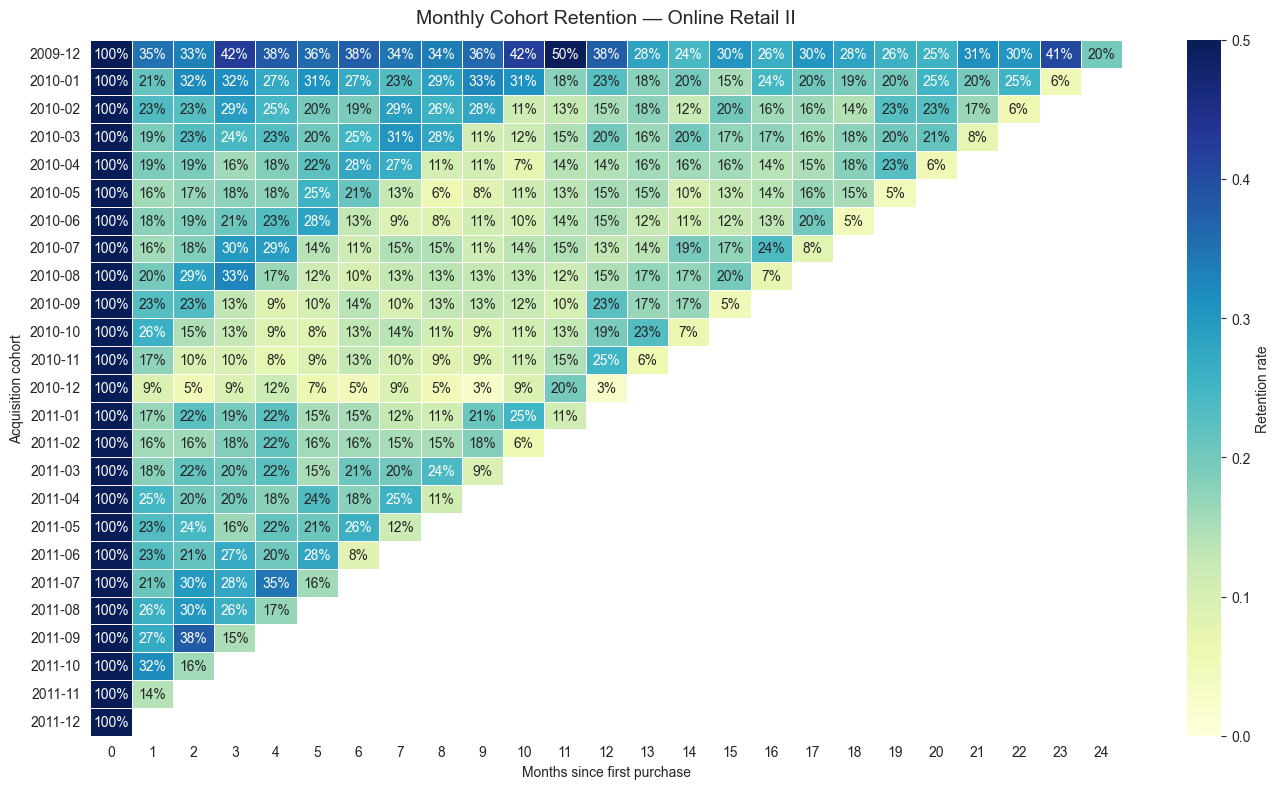

In [6]:
fig, ax = plt.subplots(figsize=(14, 8))

# Format the cohort month index as readable labels (e.g. '2010-03')
retention.index = retention.index.astype(str)

sns.heatmap(retention,
            annot=True, fmt='.0%', cmap='YlGnBu',
            vmin=0, vmax=0.5,            # cap colour scale so month-0 (100%) doesn't wash out the rest
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Retention rate'}, ax=ax)
ax.set_title('Monthly Cohort Retention — Online Retail II', fontsize=14, pad=12)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Acquisition cohort')
plt.tight_layout()
plt.show()

## 7. Average Retention Curve

Averaging down the columns (across all cohorts) gives the typical retention path. Index 0 is
always 100% by definition, so the interesting story is how far it drops at month 1 and how it
stabilises after that.

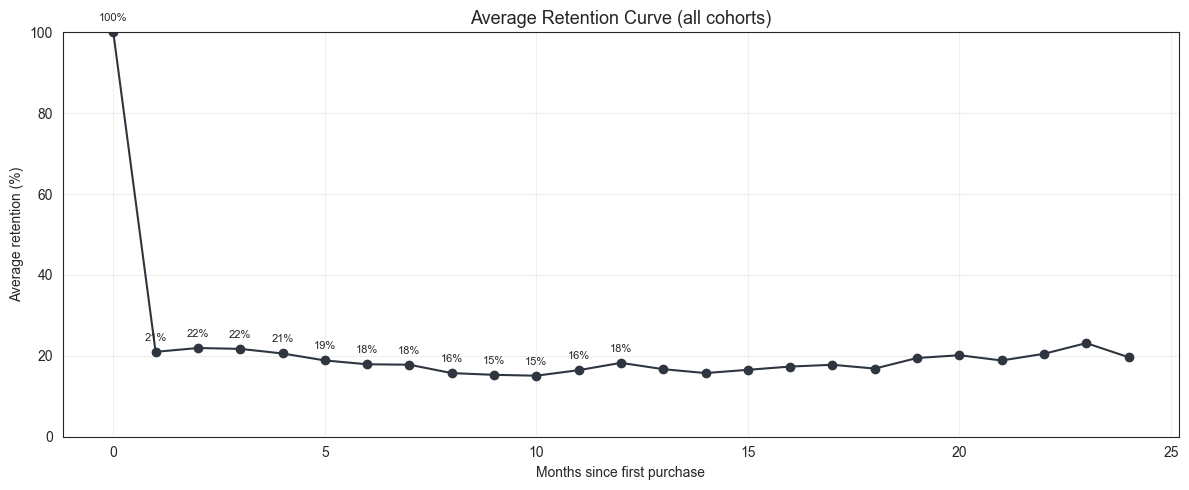

In [7]:
# Mean retention at each month-since-acquisition, across all cohorts
avg_curve = retention.mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_curve.index, avg_curve.values * 100, marker='o', color='#2f3640')
ax.set_title('Average Retention Curve (all cohorts)', fontsize=13)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Average retention (%)')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
for x, y in zip(avg_curve.index[:13], avg_curve.values[:13]):
    ax.annotate(f'{y*100:.0f}%', (x, y*100), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Headline Retention Metrics

In [8]:
# Pull out the retention figures stakeholders care about most.
# We average across cohorts that actually reach each milestone month.
def avg_at(index_month):
    return retention[index_month].mean() * 100 if index_month in retention.columns else np.nan

print('Average retention by milestone (across all cohorts):')
print(f'  Month 1  : {avg_at(1):5.1f}%')
print(f'  Month 3  : {avg_at(3):5.1f}%')
print(f'  Month 6  : {avg_at(6):5.1f}%')
print(f'  Month 12 : {avg_at(12):5.1f}%')
print()
print(f'Total customers analysed : {df["customer_id"].nunique():,}')
print(f'Number of monthly cohorts: {retention.shape[0]}')
print(f'Largest cohort           : {cohort_sizes.idxmax()} ({int(cohort_sizes.max()):,} customers)')

Average retention by milestone (across all cohorts):
  Month 1  :  21.0%
  Month 3  :  21.7%
  Month 6  :  17.9%
  Month 12 :  18.3%

Total customers analysed : 5,852
Number of monthly cohorts: 25
Largest cohort           : 2009-12 (951 customers)


## 9. Caveat — The December 2009 Cohort

One cohort behaves very differently from the rest and must be interpreted with care.

The **December 2009 cohort is not a true acquisition cohort.** Because the dataset *begins* in
December 2009, every customer who was already an established, loyal buyer before data collection
started gets recorded as "first seen" that month. As a result this cohort is by far the largest
(951 customers) and retains at roughly double the rate of every genuine later cohort.

Treating it as a normal new-customer group would overstate retention. Below we recompute the
average retention curve **excluding December 2009**, which reflects the true behaviour of
genuinely newly-acquired customers.

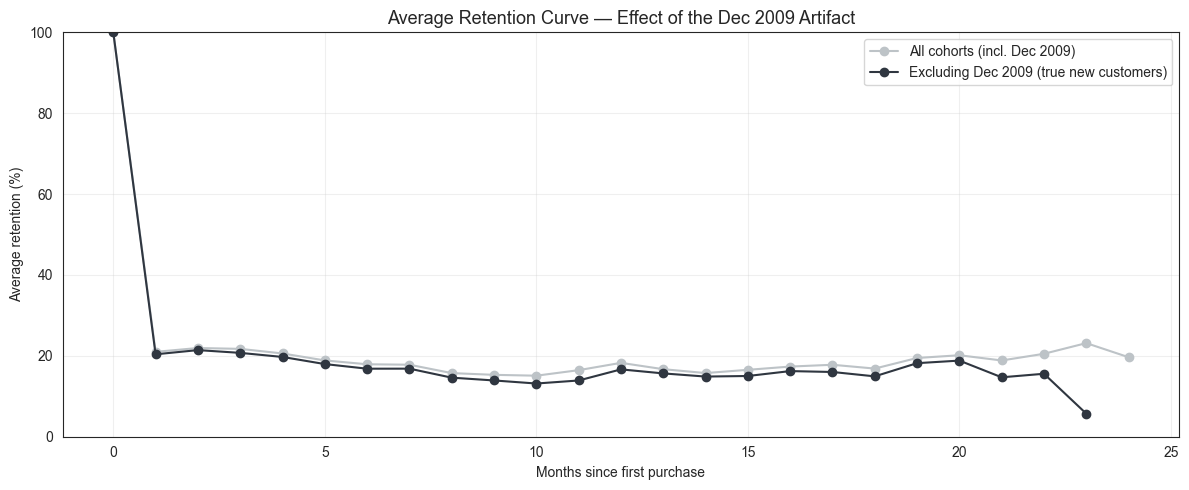

In [9]:
# Flag the Dec 2009 cohort as a pre-existing-base artifact and exclude it
dec2009 = '2009-12'
retention_excl = retention.drop(index=dec2009)

# Compare the two average curves side by side
curve_all  = retention.mean(axis=0) * 100
curve_excl = retention_excl.mean(axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(curve_all.index,  curve_all.values,  marker='o', color='#bdc3c7',
        label='All cohorts (incl. Dec 2009)')
ax.plot(curve_excl.index, curve_excl.values, marker='o', color='#2f3640',
        label='Excluding Dec 2009 (true new customers)')
ax.set_title('Average Retention Curve — Effect of the Dec 2009 Artifact', fontsize=13)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Average retention (%)')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Clean headline metrics, computed on genuine new-customer cohorts only.
# Month 1 is the most reliable figure (most cohorts reach it); later months
# average over progressively fewer cohorts due to the data ending Dec 2011.
def avg_excl(index_month):
    return retention_excl[index_month].mean() * 100 if index_month in retention_excl.columns else np.nan

print('Retention excluding the Dec 2009 artifact (genuine new customers):')
print(f'  Month 1  : {avg_excl(1):5.1f}%   <- headline metric (most reliable)')
print(f'  Month 3  : {avg_excl(3):5.1f}%')
print(f'  Month 6  : {avg_excl(6):5.1f}%')
print(f'  Month 12 : {avg_excl(12):5.1f}%')
print()
print('Note: month-by-month retention bounces because this is point-in-time')
print('retention (a customer can skip a month then return). The honest summary')
print('is a sharp month-1 drop, then stabilisation in the mid-to-high teens.')

Retention excluding the Dec 2009 artifact (genuine new customers):
  Month 1  :  20.4%   <- headline metric (most reliable)
  Month 3  :  20.7%
  Month 6  :  16.8%
  Month 12 :  16.7%

Note: month-by-month retention bounces because this is point-in-time
retention (a customer can skip a month then return). The honest summary
is a sharp month-1 drop, then stabilisation in the mid-to-high teens.


## 10. Phase 3 Summary

The retention matrix and curve quantify how well the business holds onto customers after their
first purchase. The key signals are the sharp month-1 drop (most first-time buyers do not return
the next month — normal for non-subscription retail) and the longer-term stabilisation level.
The December 2009 cohort was identified as a pre-existing-base artifact and excluded from the
headline retention figure.

**Next — Phase 4: RFM Segmentation.** We score every customer on **Recency, Frequency and
Monetary value** to divide the base into actionable segments (e.g. champions, loyal, at-risk,
lost), setting up the value modelling in Phase 5.
